# Model Accuracy Summary

Overall performance of the tuned Random Forest (`rf_tuned`, our main model) on the leakage-safe
walk-forward backtest: classification results, probabilistic accuracy (log loss / Brier), and
calibration. Reads the real backtest output `reports/predictions.parquet`. Companion to
`03_rf_diagnostics.ipynb`.


In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve

# Make the project root importable (this notebook lives in notebooks/)
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

# Shared conventions (match 03_rf_diagnostics.ipynb)
LABEL_ORDER = ["HW", "D", "AW"]
LABEL_NAMES = {"HW": "Home win", "D": "Draw", "AW": "Away win"}
PALETTE = {"HW": "#2a9d8f", "D": "#e9c46a", "AW": "#e76f51"}
PROB_COLS = ["p_home", "p_draw", "p_away"]
CLASS_IDX = {l: i for i, l in enumerate(LABEL_ORDER)}
MODEL = "rf_tuned"  # the tuned Random Forest = our main model

preds = pd.read_parquet(ROOT / "reports" / "predictions.parquet")
d = preds[preds["model"] == MODEL].reset_index(drop=True)

y_true = d["y_true"].to_numpy()
P = d[PROB_COLS].to_numpy()
y_pred = np.array(LABEL_ORDER)[P.argmax(axis=1)]

print(f"Model: {MODEL}    backtested matches: {len(d)}")
print("Models available:", preds["model"].unique().tolist())


Model: rf_tuned    backtested matches: 760
Models available: ['baseline_elo', 'log_reg', 'rf', 'rf_tuned', 'rf_recency']


## 1. Classification results
Argmax predictions vs actual outcomes — accuracy, per-class precision/recall/F1, and the confusion matrix. (Recall the draw row is expected to be low: draws are rarely the argmax.)

              precision    recall  f1-score   support

    Home win       0.52      0.83      0.64       317
        Draw       0.00      0.00      0.00       197
    Away win       0.51      0.51      0.51       246

    accuracy                           0.51       760
   macro avg       0.34      0.45      0.38       760
weighted avg       0.38      0.51      0.43       760

Accuracy: 0.5132  (always-home baseline: 0.4171)


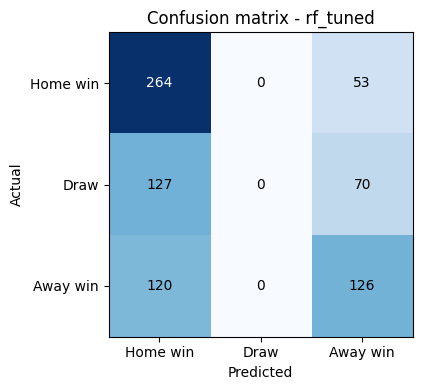

In [5]:
print(classification_report(
    y_true, y_pred, labels=LABEL_ORDER,
    target_names=[LABEL_NAMES[l] for l in LABEL_ORDER], zero_division=0,
))
print(f"Accuracy: {(y_pred == y_true).mean():.4f}  "
      f"(always-home baseline: {(d['y_true'] == 'HW').mean():.4f})")

cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
fig, ax = plt.subplots(figsize=(4.8, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels([LABEL_NAMES[l] for l in LABEL_ORDER])
ax.set_yticks(range(3)); ax.set_yticklabels([LABEL_NAMES[l] for l in LABEL_ORDER])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix - {MODEL}")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * 0.6 else "black")
plt.tight_layout(); plt.show()


## 2. Probabilistic accuracy - log loss & Brier
The metrics that matter for a probability product, with all models and the base-rate floor for context (lower is better).

       model  log_loss  brier
baseline_elo    1.0159 0.6089
    rf_tuned    1.0238 0.6137
          rf    1.0324 0.6189
     log_reg    1.0807 0.6396

Reference - base-rate log loss: 1.0798   uniform (1/3): 1.0986


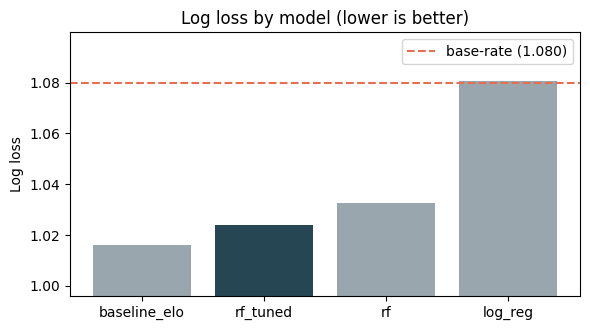

In [3]:
# Multiclass log loss + Brier for a model's prediction rows.
def multiclass_metrics(df):
    Pm = df[PROB_COLS].to_numpy()
    yi = df["y_true"].map(CLASS_IDX).to_numpy()
    ll = -np.mean(np.log(np.clip(Pm[np.arange(len(Pm)), yi], 1e-15, None)))
    onehot = np.zeros_like(Pm); onehot[np.arange(len(Pm)), yi] = 1.0
    brier = np.mean(np.sum((Pm - onehot) ** 2, axis=1))
    return ll, brier

rows = []
for m in ["baseline_elo", "rf_tuned", "rf", "log_reg"]:
    if m in preds["model"].unique():
        ll, br = multiclass_metrics(preds[preds["model"] == m])
        rows.append({"model": m, "log_loss": ll, "brier": br})
summary = pd.DataFrame(rows).sort_values("log_loss").reset_index(drop=True)

# Reference floor: always predicting the class base rates.
yi_all = d["y_true"].map(CLASS_IDX).to_numpy()
base = np.bincount(yi_all, minlength=3) / len(yi_all)
base_ll = -np.mean(np.log(base[yi_all]))

print(summary.round(4).to_string(index=False))
print(f"\nReference - base-rate log loss: {base_ll:.4f}   uniform (1/3): {np.log(3):.4f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(summary["model"], summary["log_loss"],
              color=["#264653" if m == MODEL else "#9aa6ad" for m in summary["model"]])
ax.axhline(base_ll, color="#e76f51", ls="--", label=f"base-rate ({base_ll:.3f})")
ax.set_ylabel("Log loss"); ax.set_title("Log loss by model (lower is better)")
ax.set_ylim(min(summary["log_loss"]) - 0.02, base_ll + 0.02); ax.legend()
plt.tight_layout(); plt.show()


## 3. Reliability (calibration)
Per-outcome (one-vs-rest): do predicted probabilities match observed frequencies? Points on the diagonal = well calibrated.

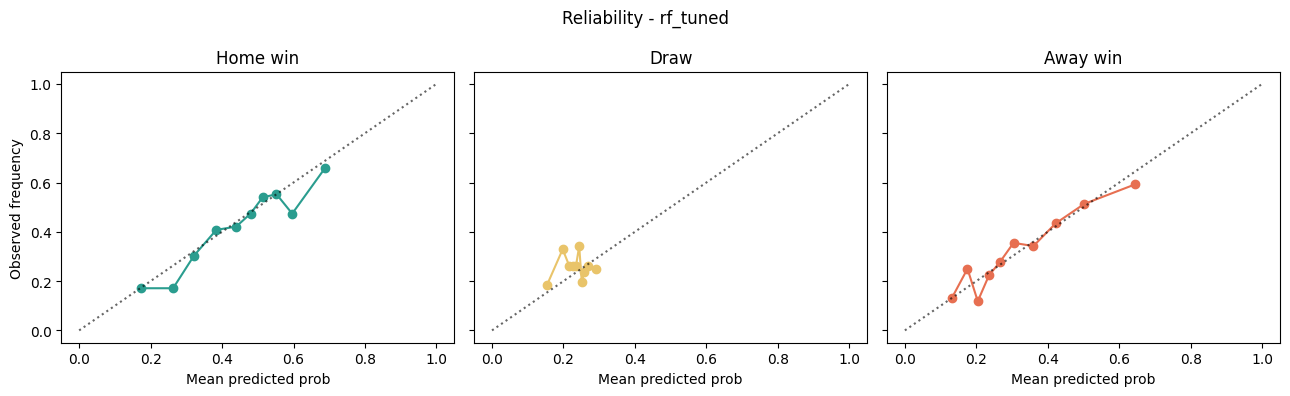

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, label, col in zip(axes, LABEL_ORDER, PROB_COLS):
    y_bin = (d["y_true"] == label).astype(int).to_numpy()
    frac_pos, mean_pred = calibration_curve(
        y_bin, d[col].to_numpy(), n_bins=10, strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, "o-", color=PALETTE[label])
    ax.plot([0, 1], [0, 1], "k:", alpha=0.6)
    ax.set_title(LABEL_NAMES[label]); ax.set_xlabel("Mean predicted prob")
axes[0].set_ylabel("Observed frequency")
fig.suptitle(f"Reliability - {MODEL}")
plt.tight_layout(); plt.show()
